# Projeto do curso 

## CAIXAVERSO - FC4 | Analista Dados - II | Análise Exploratória de Dados


### Aluno: Rafael Bechelli Paviato

In [38]:
# Padrão
import pandas as pd 
import numpy as np

# Graficos
from matplotlib import pyplot as plt
import seaborn as sns

# Estatística inferencial
from scipy.stats import norm

# Tools
import calendar

In [39]:
df = pd.read_csv('vendas_supermercado_com_cliente.csv')

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Data         20075 non-null  str    
 1   Produto      20075 non-null  str    
 2   Categoria    20075 non-null  str    
 3   Preço        20075 non-null  float64
 4   Quantidade   20075 non-null  int64  
 5   Desconto     20075 non-null  float64
 6   Total_Venda  20075 non-null  float64
 7   Idade        20075 non-null  int64  
 8   Renda        20075 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 1.4 MB


Através do resumo do pandas fica claro que temos um dataframe de qualidade inicial já razoável, sem dados nulos, e com as colunas bem formatadas com os tipos adequados, à exceção da data, que precisará ser convertida.

Visto isto, vamos observar alguns dados do dataframe para termos uma primeira idéia do que estamos tratando, e sem seguida prosseguiremos com a análise de qualiadade dos dados.

In [41]:
df.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.0,41.90,67,4419.56
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.0,30.45,29,3809.17
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.0,519.96,24,1013.42


Já vamos converter a Data para o tipo datetime e seguimos com a investigação se algum problema com os dados categóricos, ie, erros de digitação, ou categorias aberrantes.

In [42]:
df['Data'] = pd.to_datetime(df['Data'])

In [43]:
print(df['Produto'].unique())

<StringArray>
[                                          'Maçãs',
                                         'Bananas',
                                        'Laranjas',
                                         'Tomates',
                                          'Alface',
                                        'Cenouras',
                                          'Frango',
                                    'Carne bovina',
                                     'Carne suína',
                                          'Salmão',
                                         'Tilápia',
                                            'Atum',
                                     'Pão francês',
                                    'Pão integral',
                                      'Croissants',
                                           'Arroz',
                                          'Feijão',
                                        'Macarrão',
                                            'Óleo'

In [44]:
print(df['Categoria'].unique())

<StringArray>
[          'Alimentos Frescos',       'Produtos de Mercearia',
           'Laticínios e Ovos',                     'Bebidas',
         'Produtos de Limpeza', 'Produtos de Higiene Pessoal',
                  'Congelados',                    'Pet Shop',
       'Utilidades Domésticas']
Length: 9, dtype: str


Tudo certo, nenhum dado estranho ou com erro de digitação até o mommento.

Seguimos então para a avaliação dos dados quantitativos.

In [45]:
df.describe()

,Data,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
count,20075,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000
mean,2023-07-02 00:00:00,25.577109,10.007671,0.039760,245.901736,45.992827,2999.034265
min,2023-01-01 00:00:00,1.000000,1.000000,0.000000,0.910200,18.000000,1000.380000
25%,2023-04-02 00:00:00,13.260000,5.000000,0.000000,75.604500,32.000000,1993.625000
50%,2023-07-02 00:00:00,25.660000,10.000000,0.000000,186.320000,46.000000,2998.830000
75%,2023-10-01 00:00:00,37.770000,15.000000,0.000000,370.040000,60.000000,4007.675000
max,2023-12-31 00:00:00,49.990000,19.000000,0.500000,949.050000,74.000000,4999.760000
std,NaN,14.115988,5.488450,0.085011,207.773694,16.482103,1159.717376


Da tabela anterior alguns pontos já ficam estabelecidos:

- O recorte temporal é o ano de 2023 inteiro, de primeiro de janeiro à 31 de dezembro
- O preço dos produtos está num range razoável, nenhum erro aqui.
- A quantidade também parece estar dentro do range que se espera.
- Valores totais também ok, ie, sem nenhum valor negativo ou algum valor positivo fora da escala esperada.
- Idade e renda seguem também dentro da normalidade

Finalmente, vamos finalizar a análise de qualiadade dos dados procurando por duplicados.

In [46]:
df.duplicated().any()

np.False_

Visto que não temos dados duplicados encerramos a análise de qualiade. Tudo indica que se trata de uma base sintética, ou no mínimo, pré-processada. Estamos aptos agora a seguir com a análise estatística.

## Análise Preliminar Geral

A partir do describe da seção anterior, já é possivel notar através de algumas medidas de centralidade dos dados (média e mediana - expressa pelo segundo quartil ie 50%) que em geral, a média e a mediana estão bem próximas, indicando uma distribuição equilibrada (possivelmente simétrica, mas não necessariamente), menos para a coluna Total_Venda. Nesta coluna, a média é sensivelmente maior que a mediana, indicando o possivel efeito de algumas poucas vendas de valor muito elevado.

Para melhor ilustrar estes aspectos, vamos apresentar alguns gráficos que nos permitam uma visualização rápida.

O primeiro aspecto que seria interessante observar é a quantidade de vendas em cada mês. Para tanto, vamos criar uma coluna a mais no dataframe, que nos será bastante útil durante a análise.

In [47]:
df['Mes'] = df['Data'].dt.month_name()

In [48]:
df['Mes'].value_counts()

Mes
January      1705
March        1705
May          1705
July         1705
August       1705
October      1705
December     1705
April        1650
June         1650
September    1650
November     1650
February     1540
Name: count, dtype: int64

<Axes: title={'center': 'Número de vendas por mês'}, xlabel='Mes', ylabel='count'>

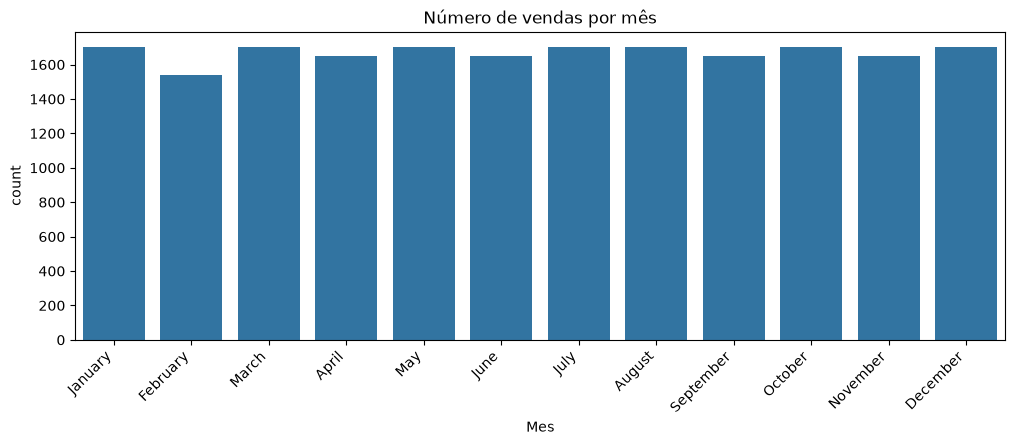

In [49]:
# Precisamos de uma lista para restabelecer a ordem cronológica depois que value_counts retornar
ordem_mensal_cronologica = list(calendar.month_name)[1:] 

plt.figure(figsize=(12,4))
plt.xticks(rotation=45, ha='right')
plt.title("Número de vendas por mês")
sns.barplot(df['Mes'].value_counts().reindex(ordem_mensal_cronologica))
#df['Mes'].head(10)

À primeira vista não parece haver diferença significativa no volume - ie, número de vendas, não faturamento - de vendas em relação aos meses do ano. Para melhor entender os dados, vamos também plotar um gráfico do faturamento de cada mês.

<Axes: title={'center': 'Faturamento por Mês'}, xlabel='Mes', ylabel='Total_Venda'>

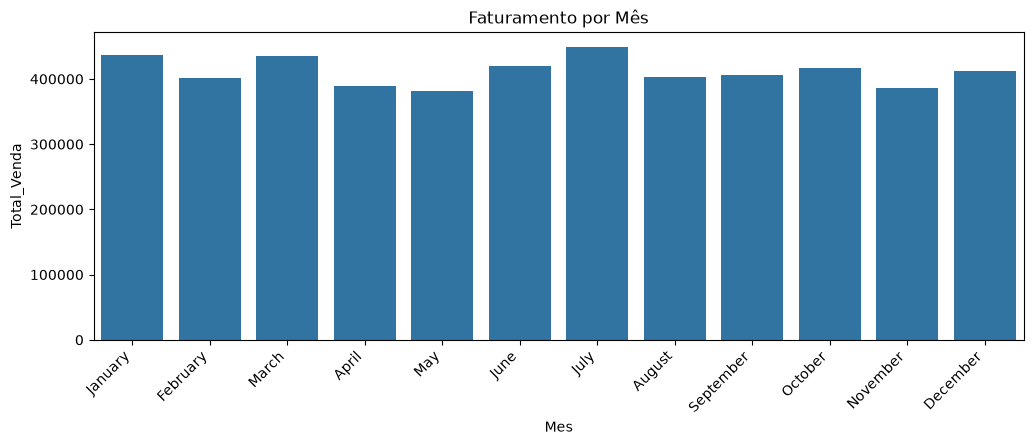

In [50]:
total_venda_por_mes = df.groupby('Mes')['Total_Venda'].sum()


plt.figure(figsize=(12,4))
plt.xticks(rotation=45, ha='right')
plt.title("Faturamento por Mês")
sns.barplot(total_venda_por_mes.reindex(ordem_mensal_cronologica))


Observa-se graficamente que também neste caso, em termos de faturamento, é difícil apontar uma tendência clara, existindo um pouco mais de variação do que no caso do volume de vendas, porém ainda podendo ser apenas decorrente das flutuações usuais oirundas de dados de natureza estocástica. Talvez temos um ponto de interesse na sequência maio, junho, julho, por apresentar uma tendência ganhos de faturamente. Mais adiante formalizaremos este tipo de análise para ter uma medida objetiva.

Agora vamos observar histogramas referentes ao preço individual dos produtos, idade dos compradores e faixa de renda.

<Axes: title={'center': 'Histograma de Peços Unitários dos Produtos das Vendas'}, xlabel='Preço', ylabel='Count'>

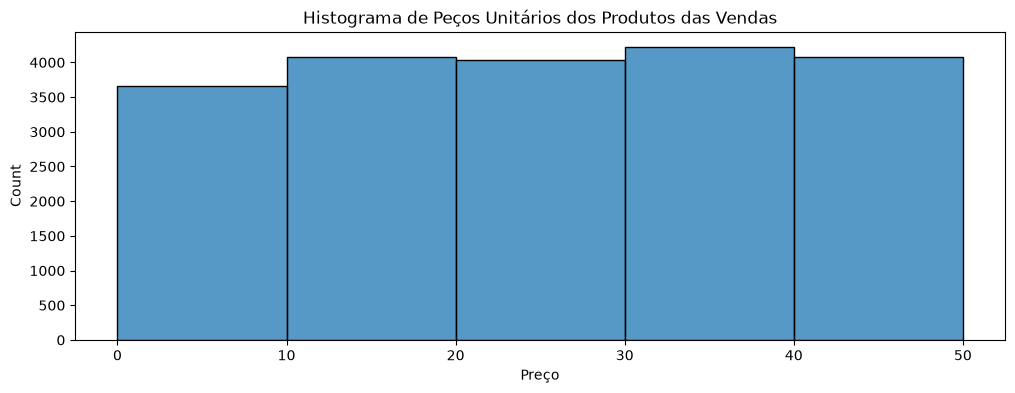

In [51]:
plt.figure(figsize=(12,4))
plt.title("Histograma de Peços Unitários dos Produtos das Vendas")
sns.histplot(data=df['Preço'], bins=[0,10,20,30,40,50])

Nota-se que a gama de produtos vendidos está bem distribuida entre produtos caros e baratos.

<Axes: title={'center': 'Histograma de Volume de Vendas por Idade'}, xlabel='Idade', ylabel='Count'>

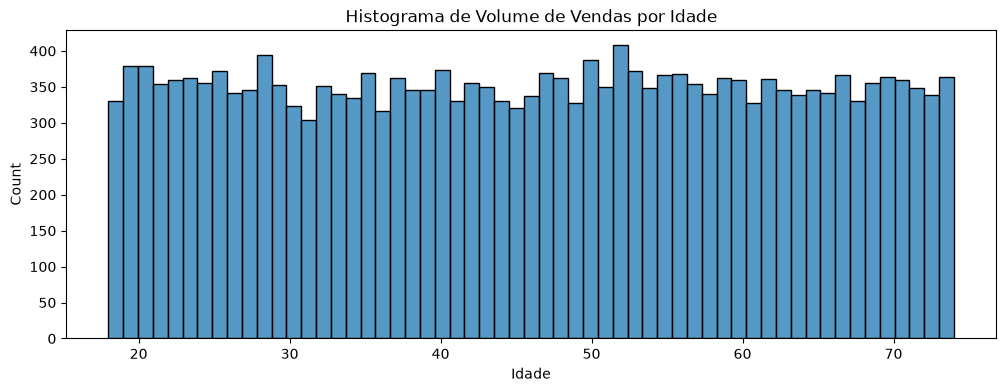

In [52]:
# A idade máxima 74 menos a idade mínia de 18, dá 56, vamos dividir em 57 bins
plt.figure(figsize=(12,4))
plt.title("Histograma de Volume de Vendas por Idade")
sns.histplot(data=df['Idade'], bins=57)

Novamente, em termos gerais, não se observa uma concentração de **volume de vendas** em nenhuma faixa etária específica.

<Axes: title={'center': 'Histograma de distribuição de renda'}, xlabel='Renda', ylabel='Count'>

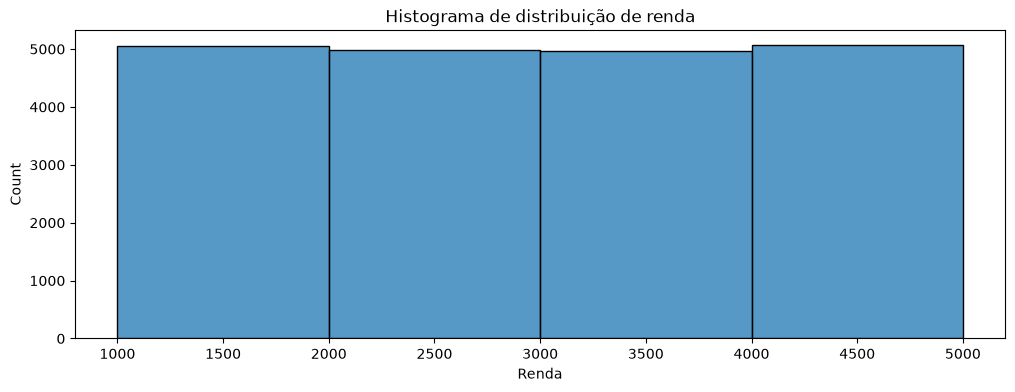

In [53]:
plt.figure(figsize=(12,4))
plt.title("Histograma de distribuição de renda")
sns.histplot(data=df['Renda'], bins=[1000,2000,3000,4000,5000])

Mais uma vez nenhum tipo de concentração específica. A renda aparece bem distribuida.

---

## Perguntas de Negócio

### #1 Quais são as categorias de produtos mais vendidos e em quais meses houve o pico de vendas destas categorias?

In [54]:
total_venda_por_categoria = df.groupby('Categoria')['Total_Venda'].sum().sort_values(ascending=False)

with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(total_venda_por_categoria)

Categoria
Alimentos Frescos             1,365,309.46
Produtos de Mercearia           529,653.65
Laticínios e Ovos               459,960.47
Bebidas                         454,394.16
Produtos de Limpeza             447,545.86
Pet Shop                        440,331.56
Produtos de Higiene Pessoal     440,039.48
Congelados                      439,720.13
Utilidades Domésticas           359,522.58
Name: Total_Venda, dtype: float64

Vê-se claramente que a categoria de Alimentos Frescos é uma ordem de grandeza maior que as demais. Com um faturamento de mais de um milhão de reais no período analisado, enquanto todas as demais apresentam faturamento menor que 530 mil. O segundo e terceiro colocados são os Produtos de Mercearia e Laticínios e Ovos. Vamos em seguinda analisar estas categorias na sua dimensão temporal.

In [55]:
top3_categorias = ['Alimentos Frescos', 'Produtos de Mercearia', 'Laticínios e Ovos']
mask = (df['Categoria'].isin(top3_categorias))

breakdown_mensal_das_categorias_que_mais_vendem = df[mask].groupby(['Categoria', 'Mes'])['Total_Venda'].sum().sort_values(ascending=False)

In [56]:
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(breakdown_mensal_das_categorias_que_mais_vendem)

Categoria              Mes      
Alimentos Frescos      March       129,103.45
                       July        126,769.38
                       June        120,631.54
                       October     116,440.75
                       January     116,281.50
                       August      114,280.75
                       September   112,849.47
                       December    111,652.58
                       February    109,234.29
                       November    105,294.10
                       May         103,923.98
                       April        98,847.67
Produtos de Mercearia  September    48,192.29
                       January      48,079.73
                       April        46,105.61
                       December     45,589.06
                       November     44,316.89
                       July         44,296.37
                       August       44,156.45
                       June         43,958.58
Laticínios e Ovos      October      43,440.80
P

In [57]:
type(breakdown_mensal_das_categorias_que_mais_vendem)

df_analise = breakdown_mensal_das_categorias_que_mais_vendem.unstack(level='Categoria')

Os **Alimentos Frescos** tiveram em **Março** seu mês de maior faturamento. Enquanto que os **Produtos de Mercearia** tiveram o record de faturamento em **setembro**, e os **Laticínios e Ovos** tiveram maior faturamento em **Outubro**. Não observa um padrão claro por enquanto. Espera-se que alimentos frescos tenham alguma componente sazonal devido as safras. Vamos olhar para o coeficiente de variação destas categorias para termos uma idéia:

In [58]:
for c in top3_categorias:
    print(f"O coeficiente de variação dos {c} é {round(100*df_analise[c].std()/df_analise[c].mean(),2)}%")

O coeficiente de variação dos Alimentos Frescos é 7.87%
O coeficiente de variação dos Produtos de Mercearia é 6.06%
O coeficiente de variação dos Laticínios e Ovos é 7.14%


São coeficientes muito parecidos. Ou seja, a dispersão destes dados de faturamento está mais ou menos a mesma entre as três categorias que mais venderam.

---

### #2 Qual foi o impacto das promoções (descontos aplicados) nas vendas? Quais produtos tiveram o maior aumento nas vendas durante as promoções?

Primeiramente vamos identificar o período em que ocorreram as promoções.

In [59]:
mask = df['Desconto'] != 0
vendas_com_desconto = df[mask]
vendas_com_desconto.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Mes
4950,2023-04-01,Maçãs,Alimentos Frescos,19.30,17,0.18,269.0420,42,3331.79,April
4951,2023-04-01,Bananas,Alimentos Frescos,3.08,16,0.22,38.4384,74,1265.90,April
4952,2023-04-01,Laranjas,Alimentos Frescos,40.32,7,0.21,222.9696,18,1861.37,April
4953,2023-04-01,Tomates,Alimentos Frescos,36.11,19,0.10,617.4810,56,4820.78,April
4954,2023-04-01,Alface,Alimentos Frescos,31.14,11,0.13,298.0098,54,4585.73,April


In [60]:
vendas_com_desconto.groupby('Mes').count()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
Mes,,,,,,,,,
April,825,825,825,825,825,825,825,825,825
August,825,825,825,825,825,825,825,825,825
December,660,660,660,660,660,660,660,660,660
May,825,825,825,825,825,825,825,825,825
November,385,385,385,385,385,385,385,385,385
October,660,660,660,660,660,660,660,660,660


In [61]:
meses_com_desconto = vendas_com_desconto.groupby('Mes').count().index.to_list()
print(meses_com_desconto)

['April', 'August', 'December', 'May', 'November', 'October']


Agora vamos fazer um comparativo entre o faturamento dos produtos nos meses sem desconto vs faturamento nos meses com desconto.

In [62]:
mask = df['Mes'].isin(meses_com_desconto)
df_com_desconto = df[mask]
df_sem_desconto = df[~mask]

<Axes: title={'center': 'Efeito dos Descontos no Faturamento dos Produtos'}, xlabel='Produto', ylabel='value'>

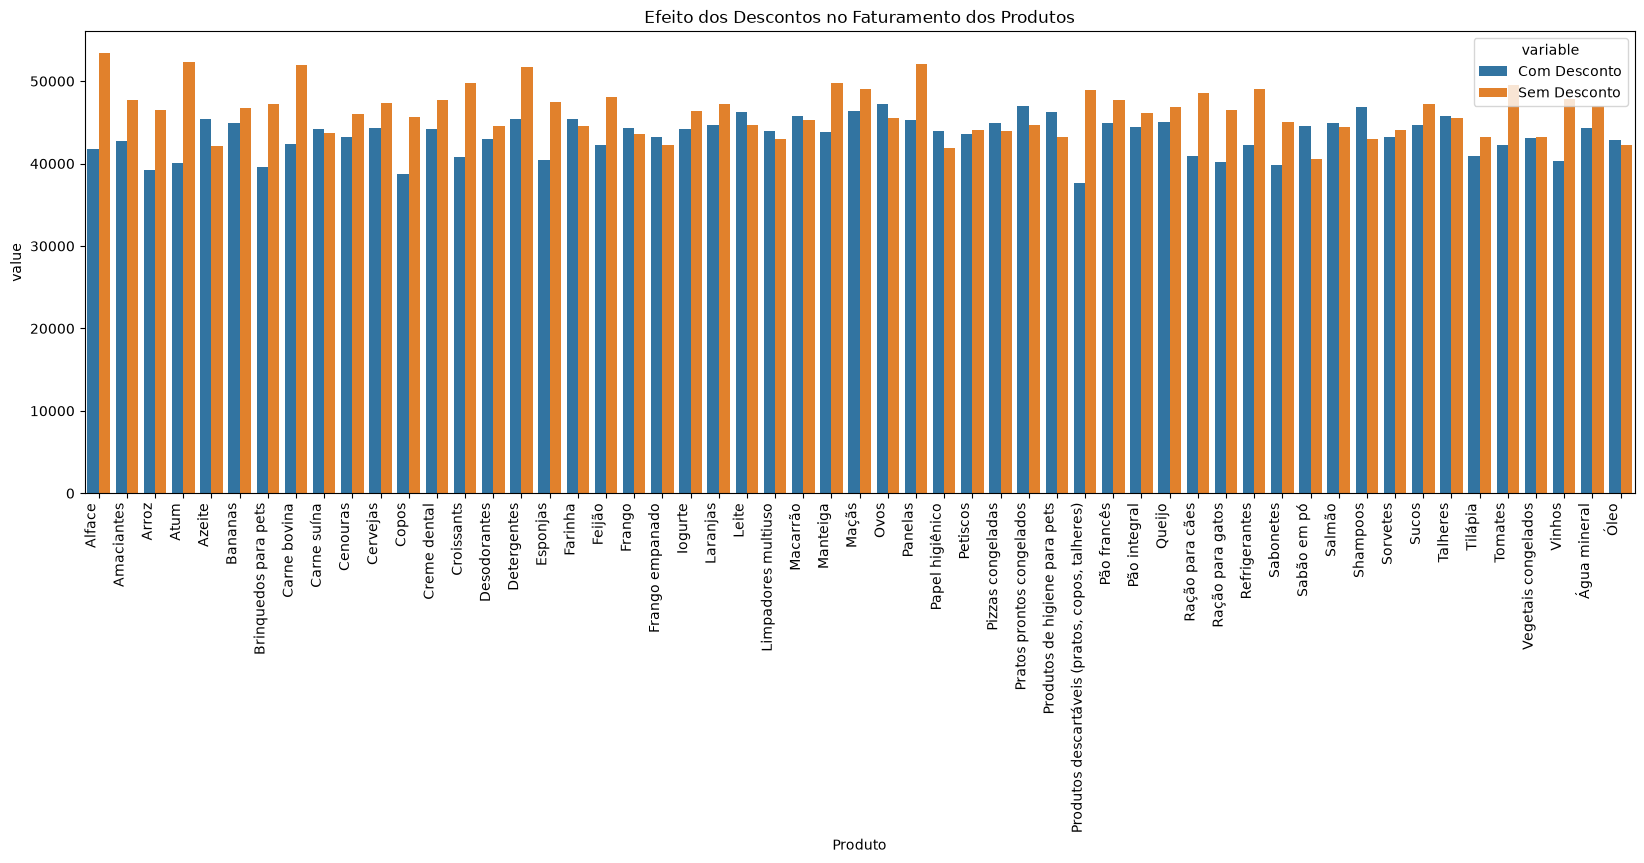

In [63]:
agrupado_com_desconto = df_com_desconto.groupby('Produto')['Total_Venda'].sum().sort_values(ascending=False)
agrupado_sem_desconto = df_sem_desconto.groupby('Produto')['Total_Venda'].sum().sort_values(ascending=False)

df_analise = pd.DataFrame({'Com Desconto' : agrupado_com_desconto, 'Sem Desconto' : agrupado_sem_desconto}).reset_index()
df_analise = pd.melt(df_analise, id_vars=["Produto"])

plt.figure(figsize=(20,6))
plt.xticks(rotation=90, ha='right')
plt.title("Efeito dos Descontos no Faturamento dos Produtos")
sns.barplot(data=df_analise,x='Produto',y='value', hue='variable' )

Com o gráfico de barras acima é possivel identificar rapidamente os produtos que tiveram maior faturamento nos meses em que os descontos foram aplicados do que nos meses sem descontos, isto é, são produtos que respondem bem à campanha, como **azeite, leite, farinha, congelados, sabão em pó, shampoo, etc.**

Vamos fazer um ranking de quais produtos respondem melhor à campanha de descontos, usando a diferença entre estes dois subconjuntos.

In [64]:

df_analise = pd.DataFrame({'Com Desconto' : agrupado_com_desconto, 'Sem Desconto' : agrupado_sem_desconto})
#df_analise.columns
df_analise['Diferença'] =  round(df_analise['Com Desconto'] - df_analise['Sem Desconto'],2)
df_analise.sort_values(by='Diferença', ascending= False).head(15)


,Com Desconto,Sem Desconto,Diferença
Produto,,,
Sabão em pó,44606.4059,40518.37,4088.04
Shampoos,46837.8542,43039.30,3798.55
Azeite,45452.9651,42134.49,3318.48
Produtos de higiene para pets,46230.0919,43269.25,2960.84
Pratos prontos congelados,47023.0620,44622.22,2400.84
Papel higiênico,43938.1344,41845.69,2092.44
Ovos,47169.2203,45572.16,1597.06
Leite,46311.0678,44730.80,1580.27
Limpadores multiuso,43993.0817,42997.49,995.59


Temos então este ranking dos produtos mais impactados positivamente pela campanha de descontos. Sabão em pó, Shampoos e Azeites são os três mais sensíveis ao programa de descontos.

Agora para finalizar vamos ver se no geral o período de descontos compensou ou não em termos de faturamento. 

In [65]:
faturamento_com_desconto = df_analise['Com Desconto'].sum()
faturamento_sem_desconto = df_analise['Sem Desconto'].sum()

print(f"Nos meses em que houve desconto o faturamento total geral foi de {faturamento_com_desconto:,.2f}")
print(f"Nos meses normais o faturamento total geral foi de {faturamento_sem_desconto:,.2f}")


Nos meses em que houve desconto o faturamento total geral foi de 2,388,364.49
Nos meses normais o faturamento total geral foi de 2,548,112.86


A empresa em geral faturou menos nos meses em que implementou a política de descontos. 

A recomendação aqui para o próximo ano é que se faça uma campanha de ofertas e descontos mais refinada, focando a ação mais nos produtos que respondem bem ao incentivo para aumentar a margem geral. Claro que existe uma componente transversal que não estamos medindo por enquanto, que tem a ver com a correlação entre produtos, ie. quanto que um desconto no produto A pode incentivar indiretamente as vendas do produto B.

---

### #3 Qual a média de vendas diária por categoria de produto ?

In [66]:
df1 = df.groupby('Categoria')['Total_Venda'].sum()

#df_analise.head()

df2 = round(df1 / 365,2)

df3 = pd.DataFrame({'Faturamento Anual':df1, 'Media Diaria': df2})

df3.sort_values(by='Media Diaria', ascending=False)

,Faturamento Anual,Media Diaria
Categoria,,
Alimentos Frescos,1.365309e+06,3740.57
Produtos de Mercearia,5.296536e+05,1451.11
Laticínios e Ovos,4.599605e+05,1260.17
Bebidas,4.543942e+05,1244.92
Produtos de Limpeza,4.475459e+05,1226.15
Pet Shop,4.403316e+05,1206.39
Produtos de Higiene Pessoal,4.400395e+05,1205.59
Congelados,4.397201e+05,1204.71
Utilidades Domésticas,3.595226e+05,984.99


---

### #4 Quais produtos apresentam a maior sazonalidade nas vendas ? 

In [67]:
df_analise = df.groupby(['Produto','Mes'])['Total_Venda'].sum()
df_long = df_analise.unstack(level='Produto')

In [68]:
df_long.head()

Produto,Alface,Amaciantes,Arroz,Atum,Azeite,Bananas,Brinquedos para pets,Carne bovina,Carne suína,Cenouras,...,Shampoos,Sorvetes,Sucos,Talheres,Tilápia,Tomates,Vegetais congelados,Vinhos,Água mineral,Óleo
Mes,,,,,,,,,,,,,,,,,,,,,
April,6960.4604,6773.3808,6370.9921,8566.0625,8104.5810,5024.0791,7009.6901,4544.6288,7196.3009,6664.2334,...,7274.0757,6050.0339,8330.4953,7478.3533,6405.7136,5134.4298,7644.9361,5256.1641,8789.0346,7507.7878
August,5872.9729,7035.3939,7853.2686,7117.7031,6905.5828,8632.0796,5875.9171,8772.0901,8860.1287,6685.9076,...,9960.0999,7997.4682,7460.8005,7669.5588,7229.9709,7018.9682,6905.8593,5885.3395,8032.6609,6021.0694
December,8324.2795,7774.9768,6164.4108,5308.9668,7997.9486,7459.3620,6230.8395,6978.6890,7944.5058,8063.7781,...,7714.2351,7553.6802,5414.5734,6877.3507,7103.6565,7339.1852,8047.3059,6440.7455,5928.8982,7052.8190
February,7983.2800,7812.2100,8424.7900,11005.6800,6254.2000,7827.8100,6175.1400,8681.7600,5962.9800,8196.1100,...,6555.9200,7453.7200,6103.4900,5707.9500,4510.4000,5538.5000,6072.2300,8601.9900,6537.5900,6751.5900
January,9757.7600,9166.9400,7123.4600,8744.6500,7581.4300,8576.3200,8455.4200,7805.6100,5801.7400,6664.2200,...,6283.8900,8739.7300,11633.9000,7177.7200,6294.0300,11492.6100,9335.4200,9927.9700,7662.0400,9130.3100


In [69]:
#(df_long['Alface'].std() / df_long['Alface'].mean())*100

temp = {}
for p in df_long.columns:
    temp[p] = round((df_long[p].std() / df_long[p].mean())*100,2)

print(temp)

df1 = pd.DataFrame(list(temp.items()), columns=['Produto', 'CV'])
df1.sort_values(by='CV',ascending=False).head()

{'Alface': np.float64(19.88), 'Amaciantes': np.float64(15.44), 'Arroz': np.float64(13.24), 'Atum': np.float64(22.52), 'Azeite': np.float64(13.55), 'Bananas': np.float64(15.58), 'Brinquedos para pets': np.float64(14.75), 'Carne bovina': np.float64(19.06), 'Carne suína': np.float64(15.15), 'Cenouras': np.float64(13.95), 'Cervejas': np.float64(20.02), 'Copos': np.float64(17.03), 'Creme dental': np.float64(18.21), 'Croissants': np.float64(21.58), 'Desodorantes': np.float64(16.36), 'Detergentes': np.float64(15.78), 'Esponjas': np.float64(18.95), 'Farinha': np.float64(14.93), 'Feijão': np.float64(17.95), 'Frango': np.float64(17.07), 'Frango empanado': np.float64(11.15), 'Iogurte': np.float64(16.69), 'Laranjas': np.float64(14.77), 'Leite': np.float64(11.53), 'Limpadores multiuso': np.float64(13.73), 'Macarrão': np.float64(12.43), 'Manteiga': np.float64(13.46), 'Maçãs': np.float64(16.13), 'Ovos': np.float64(17.95), 'Panelas': np.float64(13.21), 'Papel higiênico': np.float64(8.24), 'Petiscos': 

,Produto,CV
35,"Produtos descartáveis (pratos, copos, talheres)",23.07
52,Vinhos,22.98
47,Sucos,22.87
3,Atum,22.52
50,Tomates,22.33


Temos na tabela acima os 5 produtos com maior variabilidade mensal de faturamento.

---
### #5 Quais as faixas etárias contribuíram mais para as vendas totais?

<Axes: title={'center': 'Faturamento por Idade do Cliente'}, xlabel='Idade', ylabel='Total_Venda'>

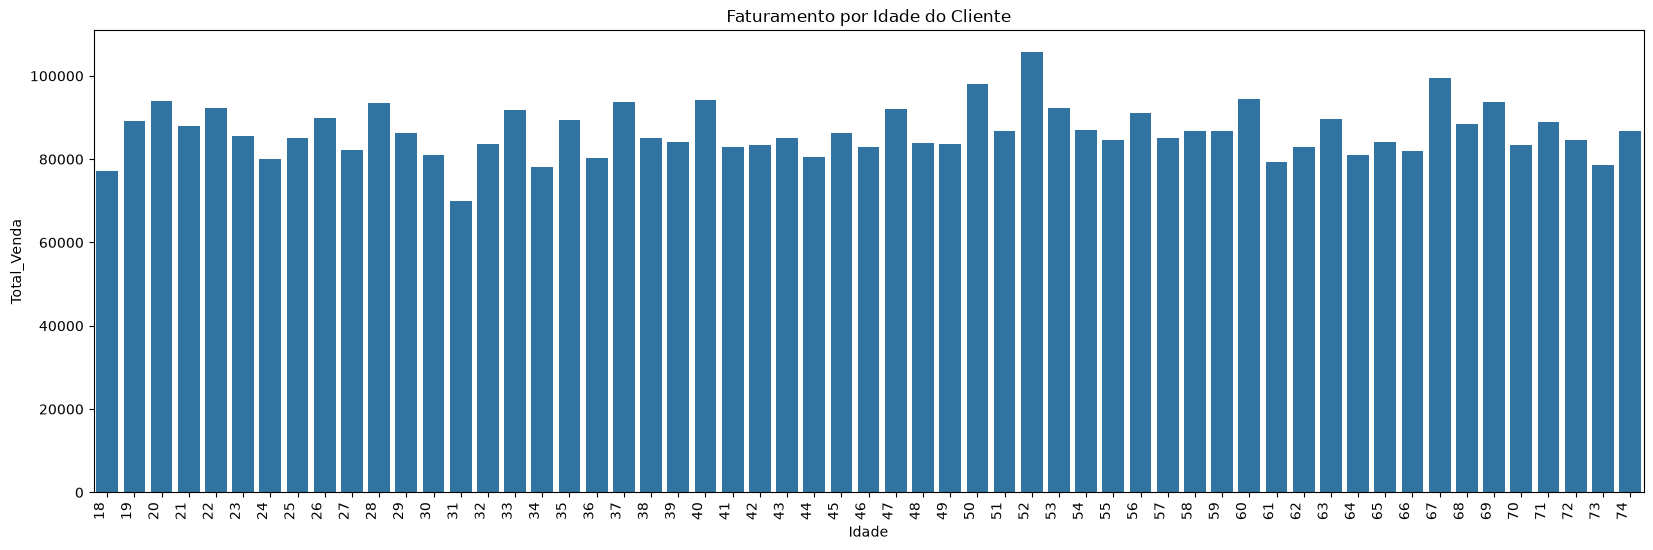

In [70]:
df_analise = df.groupby('Idade')['Total_Venda'].sum()

plt.figure(figsize=(20,6))
plt.xticks(rotation=90, ha='right')
plt.title("Faturamento por Idade do Cliente")
sns.barplot(data=df_analise)

No gráfico de barras acima não há um indício de que exista uma faixa de idades que consome sensivelmente mais, visualmente, entre 45 e 55 parece have um leve volume adicional.

Vamos categorizar as idades em : entre 18 e 35 (jovem), entre 36 e 59 (adulto) e acima de 60 anos (idoso)

In [85]:
def classificador_de_idade(x):
    if (18 <= x <= 35):
        return 'jovem'
    elif (36 <= x <= 59):
        return 'adulto'
    elif ( 60 <= x):
        return 'idoso'
    else:
        return 'NA'

df['Faixa Etaria'] = df['Idade'].map(classificador_de_idade)

#df.head()
#df['Faixa Etaria'].value_counts()

df_analise = df.groupby('Faixa Etaria')['Total_Venda'].sum().sort_values(ascending=False)


with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(df_analise)

Faixa Etaria
adulto   2,102,041.77
jovem    1,537,183.38
idoso    1,297,252.20
Name: Total_Venda, dtype: float64

<Axes: title={'center': 'Faturamento por Faixa Etária'}, xlabel='Faixa Etaria', ylabel='Total_Venda'>

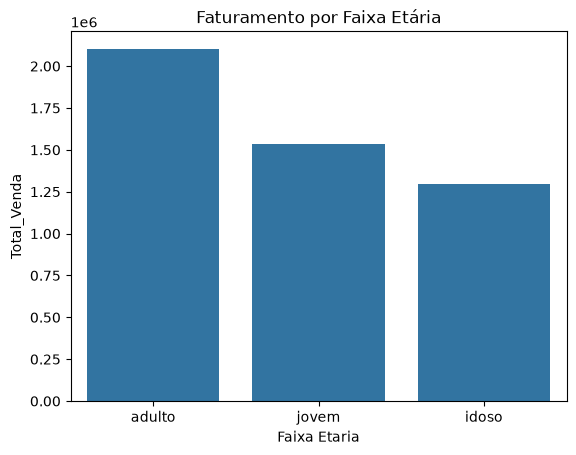

In [86]:
plt.title("Faturamento por Faixa Etária")
sns.barplot(data=df_analise)

Está claro, que os adultos ssão os que mais consumem (em termos de faturamento), porém, é um efeito mais marcado pelo tamanho da categoria do que pelo consumo per capita real.

---

### #6 Qual a distribuição das vendas ao longo dos dias da semana?

Para proceder com esta análise vamos criar a coluna específica para isso.

<Axes: xlabel='Dia da Semana', ylabel='Total_Venda'>

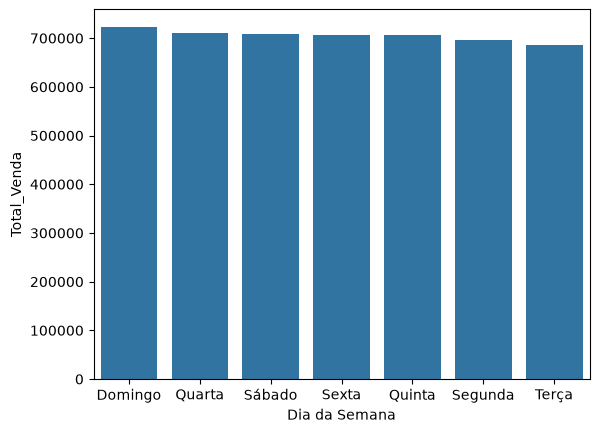

In [87]:
df['Dia da Semana'] = df['Data'].dt.day_name(locale="pt_BR.utf8")

df_analise = df.groupby('Dia da Semana')['Total_Venda'].sum()

sns.barplot(df_analise.sort_values(ascending=False))

Podemos ver que domingo é o dia que vende mais, porém, em termos relativos a diferença é marginal.

---

### #7 Como as vendas mensais se comparam antes e durante a Black Friday?

Em 2023, a semana oficial da Black Friday (conhecida como Black Week) começou no dia 20 de novembro (segunda-feira) e terminou oficialmente no dia 26 de novembro (domingo). Vamos fazer uma filtragem então para compararmos um mes antes e o mes da back.

In [74]:
#df1 = df[('2023-11-13' <= df['Data']) | (df['Data'] <= '2023-11-19')]   #Antes da Black
#df2 = df[('2023-11-20' <= df['Data']) | (df['Data'] <= '2023-11-26')]   #Durante da Black

df1 = df[df['Mes'] == 'October']     #Antes da Black
df2 = df[df['Mes'] == 'November']    #Durante a Black

In [75]:
print(f"No mês anterior à Black Friday o faturamento foi de : {df1['Total_Venda'].sum():,.2f} Reais.")
print(f"No mês corrente à Black Friday o faturamento foi de : {df2['Total_Venda'].sum():,.2f} Reais.")


No mês anterior à Black Friday o faturamento foi de : 416,884.85 Reais.
No mês corrente à Black Friday o faturamento foi de : 385,743.38 Reais.


---

### #10 Comparando a semana da "Black Friday" com a do Natal

Obs.: Trocamos aqui a pergunta 10 do PDF com a pergunta 8, pra ficar mais dentro da sequencia, já que estamos tratando das análises da Black Friday


In [193]:
df_natal = df[(df['Data'] >= '2023-12-19') & (df['Data'] <= '2023-12-25') ]   #Semana do Natal
df_black = df[(df['Data'] >= '2023-11-20') & (df['Data'] <= '2023-11-26') ]   #Semana da Black


v1 = df_natal['Total_Venda'].sum()
v2 = df_black['Total_Venda'].sum()

print(f"Na semana do natal a empresa faturou : {v1:,.2f} BRL")
print(f"Na semana da black a empresa faturou : {v2:,.2f} BRL")

print(f"A empresa faturou no natal {round(((v1/v2)-1)*100,2)}% a mais do que na black.")

Na semana do natal a empresa faturou : 86,191.23 BRL
Na semana da black a empresa faturou : 76,452.08 BRL
A empresa faturou no natal 12.74% a mais do que na black.


---


### #8 Qual é o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre diferentes categorias de produto?

In [179]:
jovens = df[df['Faixa Etaria'] == 'jovem']
n_vendas_jovens = jovens.shape[0]
ticket_medio_jovens = round(jovens['Total_Venda'].sum()/n_vendas_jovens,2)

adultos = df[df['Faixa Etaria'] == 'adulto']
n_vendas_adultos = adultos.shape[0]
ticket_medio_adultos = round(adultos['Total_Venda'].sum()/n_vendas_adultos,2)

idosos = df[df['Faixa Etaria'] == 'idoso']
n_vendas_idosos = idosos.shape[0]
ticket_medio_idosos = round(idosos['Total_Venda'].sum()/n_vendas_idosos,2)

print(f"Ticket Médio do público jovem = {ticket_medio_jovens:,.2f} BRL")
print(f"Ticket Médio do público adulto = {ticket_medio_adultos:,.2f} BRL")
print(f"Ticket Médio do público idoso = {ticket_medio_idosos:,.2f} BRL")




Ticket Médio do público jovem = 242.19 BRL
Ticket Médio do público adulto = 247.79 BRL
Ticket Médio do público idoso = 247.33 BRL


Praticamente não há diferença significativa entre o publico adulto e o idoso. Os jovens, por sua vez, gastam em média um pouco a menos, mas ainda assim é uma diferença muito pequena.

20075


<Axes: title={'center': 'Ticket Médio por Categoria de Produto'}, xlabel='Categoria', ylabel='Total_Venda'>

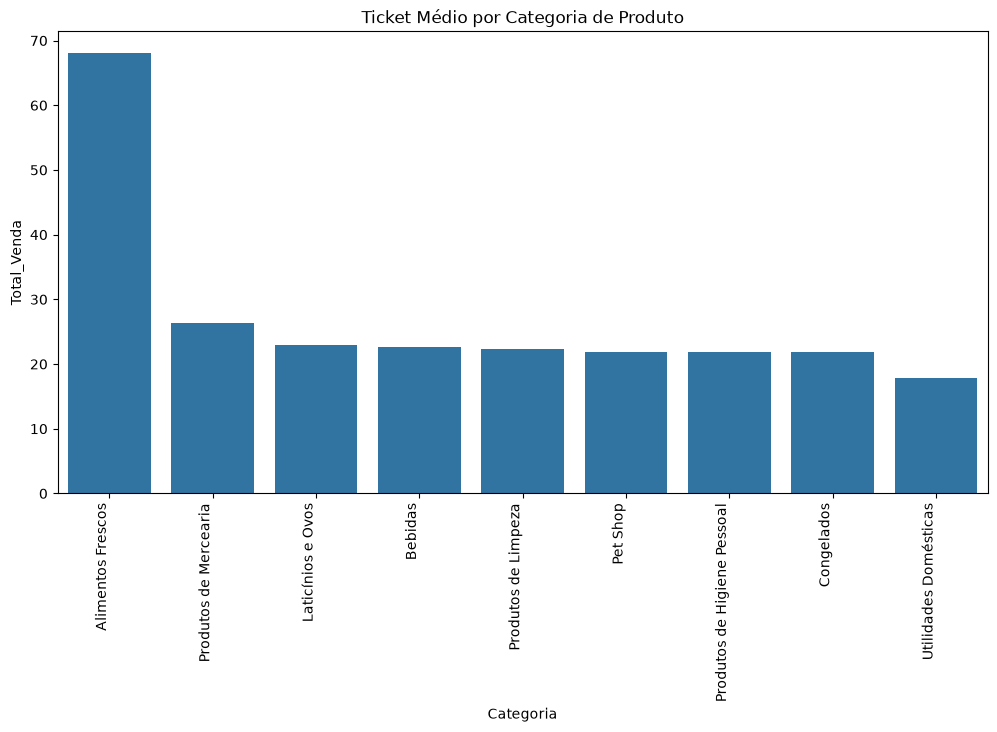

In [97]:
# Agora vamos ver qual é o valor do ticket por categoria.

n_vendas = df.shape[0]
print(n_vendas)

df_analise = df.groupby('Categoria')['Total_Venda'].sum()
tm = df_analise.map(lambda x: round(x/n_vendas,2)).sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.title('Ticket Médio por Categoria de Produto')
plt.xticks(rotation=90, ha='right')
sns.barplot(data=tm)

Nota-se, em concordância com o que já havíamos visto anteriormente sobre o faturamento por categorias, que o ticket médio mais elevado é de fato o dos **alimentos frescos**. Todos os outros são mais ou menos iguais.

---


### #9 Qual é a relação entre a idade dos clientes e o valor total das compras?

Esta ja está contemplada na pergunta #5, basta olhar o gráfico do faturamento vs Faixa Etária

---


### #11 O aumento nas vendas durante períodos de promoção (descontos) é estatisticamente significativo, ou pode ser explicado por variação aleatória?

Vimos em #2 que o faturamento geral dos meses com desconto foi menor que o faturamento dos meses sem desconto. Vamos analisar agora a influencia da campanha de descontos quanto ao número de vendas.

In [115]:
print(df.shape[0])
print(meses_com_desconto)

df_com_desconto = df[df['Mes'].isin(meses_com_desconto)]
n_cd = df_com_desconto.shape[0]

df_sem_desconto = df[~df['Mes'].isin(meses_com_desconto)]
n_sd = df_sem_desconto.shape[0]

print(f"Numero de vendas em meses COM desconto: {n_cd}")
print(f"Numero de vendas em meses SEM desconto: {n_sd}")

p1 = round(n_cd / df.shape[0],6)
p2 = round(n_sd / df.shape[0],6)

print(f"proporção de vendas em meses COM descontos p1 = {p1}")
print(f"proporção de vendas em meses SEM descontos p2 = {p2}")



20075
['April', 'August', 'December', 'May', 'November', 'October']
Numero de vendas em meses COM desconto: 10120
Numero de vendas em meses SEM desconto: 9955
proporção de vendas em meses COM descontos p1 = 0.50411
proporção de vendas em meses SEM descontos p2 = 0.49589


Temos ai uma diferença de aprox. 1% entre as vendas nos dois momentos, na campanha de descontos e fora dela. VAmos proceder com o teste de hipótese para determinarmos se esta diferença é significativa ou não.

$$ H_0 : \text{Não há diferença entre p1 e p2} $$

$$ H_1 : \text{Há diferença entre p1 e p2} $$

Adotaremos o nivel se significancia $ \alpha = 0.05$

Antes de mais nada, vamos verificar que estamos em condições de aplicar a teoria. Note que ambas amostras são independentes, e as desigualdades abaixo se verificam:

In [120]:
if (n_cd*p1 > 10 & (n_cd*(1-p1) > 10)):
     print("Condiçao OK")

if (n_cd*p1 > 10 & (n_cd*(1-p1) > 10)):
     print("Condiçao OK")

Condiçao OK
Condiçao OK


In [130]:
# Determinando o Nivel de Significancia e Calculando o Standard Error

ALFA = 0.05
SE= np.sqrt((p1*(1-p1)/n_cd) + (p2*(1-p2)/n_sd))


In [125]:
z_score = ((p1 - p2) - 0)/SE
print(z_score)

1.1646611731868242


In [131]:
p_valor = (1 - norm.cdf(z_score)) * 2 
print(p_valor)

if p_valor > ALFA :
    print("Aceitamos H0")
else:
    print("Rejeitamos H0")

0.24415617128412803
Aceitamos H0


Portanto, a um nivel de significância de 5% aceitamos a hipótese nula, ou seja, não há diferença significativa entre as proporções de vendas entre o período de campanha e o período sem campanha. A diferença observada é produto das flutuações das variáveis aleatórias.

----

### #12 O desempenho de vendas da semana da Black Friday é estatisticamente diferente do desempenho da semana do Natal ?

A diferença pode ser explicada por variação natural entre semanas? Utilize um teste A/B
(teste t para duas amostras independentes) comparando as vendas diárias das duas semanas, e construa também
intervalos de confiança de 95% para a média de vendas diárias de cada uma.

    H_0 : A média das vendas entre as semanas é a mesma
    H_1 : A média das vendas entre as semanas é diferente

In [237]:
mu = 0

#Parametros Semana da Black
x1 = df_black['Total_Venda'].mean()   
sigma1 = df_black['Total_Venda'].std()
n1 = df_black.shape[0]

#Parametros Semana do Natal
x2 = df_natal['Total_Venda'].mean()
sigma2 = df_natal['Total_Venda'].std()
n2 = df_natal.shape[0]

Z = ((x1-x2) - mu)/np.sqrt(sigma1**2/n1 + sigma2**2/n2)
print(abs(Z))
print(f"Média de vendas na semana da Black = {x1:,.2f}")
print(f"Média de vendas na semana do Natal = {x2:,.2f}")


1.8200524718128102
Média de vendas na semana da Black = 198.58
Média de vendas na semana do Natal = 223.87


In [231]:
p_valor = (1 - norm.cdf(np.abs(Z))) * 2 
print(p_valor)

0.0687510145221164


In [235]:
if p_valor < ALFA:
    print(f'p_valor = {round(p_valor,3)} < {ALFA}  --- REJEITAMOS H0')
else:
    print(f'p_valor = {round(p_valor,3)} >= {ALFA} --- ACEITAMOS H0')

p_valor = 0.069 >= 0.05 --- ACEITAMOS H0


Conluímos que a semana da black e a semana do natal não tem diferença significativa entre o valor da média das vendas.

Como havíamos visto na quesão #10, a empresa faturou no natal 12.74% a mais do que na black, porém, a conclusão desta analise anterior é que o valor médio das vendas não tem diferença significativa.


---


### #13 Qual é a estimativa, com 95% de confiança, do ticket médio geral da loja e do ticket médio por faixa etária?

Construa os intervalos de confiança correspondentes e discuta o que a amplitude de cada intervalo revela sobre a variabilidade do comportamento de compra em cada grupo.

In [134]:
ticket_medio_geral = round(df['Total_Venda'].sum()/df.shape[0],2)

print(f"Ticket Médio Geral = {ticket_medio_geral}")
print(f"Ticket Médio Jovens = {ticket_medio_jovens}")
print(f"Ticket Médio Adultos = {ticket_medio_adultos}")
print(f"Ticket Médio Idosos = {ticket_medio_idosos}")



Ticket Médio Geral = 245.9
Ticket Médio Jovens = 242.19
Ticket Médio Adultos = 247.79
Ticket Médio Idosos = 247.33


In [136]:
z = norm.ppf(0.95 + ALFA/2)
print(z)

1.959963984540054


Primeiro vamos analisar o intervalo de confiança para o ticket médio geral:

In [150]:
N = df.shape[0]
sigma = df['Total_Venda'].std()

limite_inferior = round(ticket_medio_geral - z*(sigma/ np.sqrt(N)),2)
limite_superior = round(ticket_medio_geral + z*(sigma/ np.sqrt(N)),2)

print(f"O ticket médio geral T está, com 95% de confiança, dentro do intervalo : {limite_inferior:,.2f} < T < {limite_superior:,.2f} ")

O ticket médio geral T está, com 95% de confiança, dentro do intervalo : 243.03 < T < 248.77 


Agora vamos analisar os intervalos de confiança do ticket médio por faixa etária:

In [177]:
N_JOVEM =  jovens.shape[0]
N_ADULTO = adultos.shape[0]
N_IDOSO = idosos.shape[0]


sigma_jovem = jovens['Total_Venda'].std()
sigma_adulto = adultos['Total_Venda'].std()
sigma_idoso = idosos['Total_Venda'].std()


#print(N_JOVEM, N_ADULTO, N_IDOSO)
#print(sigma_jovem,sigma_adulto,sigma_idoso)
#print(ticket_medio_jovens,ticket_medio_adultos, ticket_medio_idosos)
#print(z)


limite_inferior_jovem = round(ticket_medio_jovens - z*sigma_jovem/np.sqrt(N_JOVEM),2)
limite_superior_jovem = round(ticket_medio_jovens + z*sigma_jovem/np.sqrt(N_JOVEM),2)
print(f"O ticket médio JOVEM T_JOVEM está, com 95% de confiança, dentro do intervalo : {limite_inferior_jovem:,.2f} < T_JOVEM < {limite_superior_jovem:,.2f} ")

limite_inferior_adulto = round(ticket_medio_adultos - z*sigma_adulto/np.sqrt(N_JOVEM),2)
limite_superior_adulto = round(ticket_medio_adultos + z*sigma_adulto/np.sqrt(N_JOVEM),2)
print(f"O ticket médio ADULTO T_ADULTO está, com 95% de confiança, dentro do intervalo : {limite_inferior_adulto:,.2f} < T_ADULTO < {limite_superior_adulto:,.2f} ")

limite_inferior_idoso = round(ticket_medio_idosos - z*sigma_idoso/np.sqrt(N_IDOSO),2)
limite_superior_idoso = round(ticket_medio_idosos + z*sigma_idoso/np.sqrt(N_IDOSO),2)
print(f"O ticket médio ADULTO T_IDOSO está, com 95% de confiança, dentro do intervalo : {limite_inferior_idoso:,.2f} < T_IDOSO < {limite_superior_idoso:,.2f} ")
print('---')
print(f"DELTA_JOVEM = {limite_superior_jovem - limite_inferior_jovem:,.2f}")
print(f"DELTA_ADULTO = {limite_superior_adulto - limite_inferior_adulto:,.2f}")
print(f"DELTA_IDOSO = {limite_superior_idoso - limite_inferior_idoso:,.2f}")


#obs. Claro que poderíamos ter feito algo mais idiomático e não ficar repetindo blocos iguais, mas pela clareza e facilidade de correção vou deixar assim mesmo.

O ticket médio JOVEM T_JOVEM está, com 95% de confiança, dentro do intervalo : 237.13 < T_JOVEM < 247.25 
O ticket médio ADULTO T_ADULTO está, com 95% de confiança, dentro do intervalo : 242.64 < T_ADULTO < 252.94 
O ticket médio ADULTO T_IDOSO está, com 95% de confiança, dentro do intervalo : 241.72 < T_IDOSO < 252.94 
---
DELTA_JOVEM = 10.12
DELTA_ADULTO = 10.30
DELTA_IDOSO = 11.22


O intervalo de confiança para os ticket médio dos idosos é ligeiramente mais elevado do que o do publico jovem ou adulto. 

Então, se para termos o mesmo nível de confiança (ie 95%) no estimador precisamos de um intervalo mais amplo, isto nos informa que a variabilidade relativa (ie, sigma / sqrt(N)) destes dados é maior.

---

### #14 O aumento de vendas durante a Black Friday (pergunta 7) é estatisticamente significativo, ou pode ser explicado por variação natural entre os meses? 

Utilize um teste A/B comparando o valor médio de vendas no mês da Black Friday com o mês anterior.

In [211]:
df_mes_da_black = df[df['Mes'] == 'November' ]   
df_mes_antes    = df[df['Mes'] == 'October' ]    
df_demais_meses = df[df['Mes'] != 'November' ]
#df_mes_da_black

In [212]:
print(f"Valor médio de vendas no mês na black : {df_mes_da_black['Total_Venda'].mean():,.2f}")
print(f"Valor medio de vendas no mês anterior : {df_mes_antes['Total_Venda'].mean():,.2f}")
print(f"Valor medio de vendas no demais meses : {df_demais_meses['Total_Venda'].mean():,.2f}")


Valor médio de vendas no mês na black : 233.78
Valor medio de vendas no mês anterior : 244.51
Valor medio de vendas no demais meses : 246.99


Segundo os dados, aparentemente, a Black Friday foi detrimental para as vendas

In [207]:
df_analise = df.groupby('Mes')['Total_Venda'].mean()
df_analise

Mes
April        236.185802
August       236.249822
December     241.401042
February     260.385110
January      256.111267
July         263.775232
June         254.207000
March        254.894534
May          223.832820
November     233.783867
October      244.507244
September    246.470655
Name: Total_Venda, dtype: float64

Vamos fazer a as seguintes hipóteses : 

$$ H_0 : \text{O mês de novembro apresenta não apresenta diferença na média de vendas em relação à média dos outros meses} $$
$$ H_1 : \text{O mês de novembro apresenta alguma diferença na média de vendas em relação a média dos outros meses} $$

Novamente utilizaremos $\alpha = 0.05$

In [226]:
mu = 0  # Supomos que a diferença média entre as vendas de meses da população é zero

x1 = df_mes_da_black['Total_Venda'].mean()
sigma1 = df_mes_da_black['Total_Venda'].std()
n1 = df_mes_da_black.shape[0]

x2 = df_demais_meses['Total_Venda'].mean()
sigma2 = df_demais_meses['Total_Venda'].std()
n2 = df_demais_meses.shape[0]

Z = ((x1-x2) - mu)/np.sqrt(sigma1**2/n1 + sigma2**2/n2)

print(Z)

-2.493049743974676


In [222]:
p_valor = (1 - norm.cdf(np.abs(Z))) * 2 
print(p_valor)

0.012665110137941804


In [224]:
if p_valor < ALFA:
    print(f'p_valor = {p_valor} < {ALFA}  --- REJEITAMOS H0')
else:
    print('Aceitamos H0')

p_valor = 0.012665110137941804 < 0.05  --- REJEITAMOS H0


Ou seja, há sim, uma diferença na média de vendas no mês da black friday, a um nivel de significancia de 5% ou um nivel de confiabilidadade de 95%. Neste caso, porém , o efeito que era esperado, de um aumento nas vendas, foi o oposto, houve um declínio nas vendas.